In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM
import keras.backend as K
from keras import metrics
from keras.callbacks import EarlyStopping

import swifter

from Utils.preprocessing import *

from matplotlib import pyplot
import warnings


warnings.filterwarnings('ignore')



[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-d

In [3]:
train = pd.read_csv('./Data/train_labelled.csv')
val = pd.read_csv('./Data/val_labelled.csv')
test = pd.read_csv('./Data/test_labelled.csv')


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

ind = []
for i, s in enumerate(train["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]
train = train.drop(index=ind)
print(train.shape)

ind = []
for i, s in enumerate(val["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]
val = val.drop(index=ind)
print(val.shape)

ind = []
for i, s in enumerate(test["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]

test = test.drop(index=ind)
print(test.shape)

In [ ]:
X_train = train['title'].swifter.apply(preprocess_text).to_list()
y_train = np.array(train['sentiment_label'])

X_val = val['title'].swifter.apply(preprocess_text).to_list()
y_val = np.array(val['sentiment_label'])


X_test = test['title'].swifter.apply(preprocess_text).to_list()
y_test = np.array(test['sentiment_label'])


Pandas Apply:   0%|          | 0/825 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/46 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/390 [00:00<?, ?it/s]

In [6]:

# Hyperparameters
vocab_size = 10000
embedding_dim = 16
max_length = 20
trunc_type = 'post'
padding_type = 'post'
oov_token = "<OOV>"

# Tokenization and padding
tokenizer = Tokenizer(num_words=vocab_size, 
                      filters='#$%&()*+-<=>@[\\]^_`{|}~\t\n',
                      lower = False,
                      oov_token=oov_token)
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(X_train)
X_train_ = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

tokenizer.fit_on_texts(X_val)
sequences = tokenizer.texts_to_sequences(X_val)
X_val_ = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

Epoch 1/50
9/9 - 3s - loss: 0.6940 - accuracy: 0.4800 - val_loss: 0.6932 - val_accuracy: 0.5000 - 3s/epoch - 318ms/step
Epoch 2/50
9/9 - 0s - loss: 0.6936 - accuracy: 0.4715 - val_loss: 0.6931 - val_accuracy: 0.5000 - 162ms/epoch - 18ms/step
Epoch 3/50
9/9 - 0s - loss: 0.6932 - accuracy: 0.5115 - val_loss: 0.6932 - val_accuracy: 0.5000 - 157ms/epoch - 17ms/step
Epoch 4/50
9/9 - 0s - loss: 0.6932 - accuracy: 0.5042 - val_loss: 0.6932 - val_accuracy: 0.5000 - 151ms/epoch - 17ms/step
Epoch 5/50
9/9 - 0s - loss: 0.6931 - accuracy: 0.4982 - val_loss: 0.6932 - val_accuracy: 0.5000 - 201ms/epoch - 22ms/step
Epoch 6/50
Restoring model weights from the end of the best epoch: 1.
9/9 - 0s - loss: 0.6930 - accuracy: 0.5236 - val_loss: 0.6932 - val_accuracy: 0.5000 - 153ms/epoch - 17ms/step
Epoch 6: early stopping
Train: 0.499, Test: 0.500


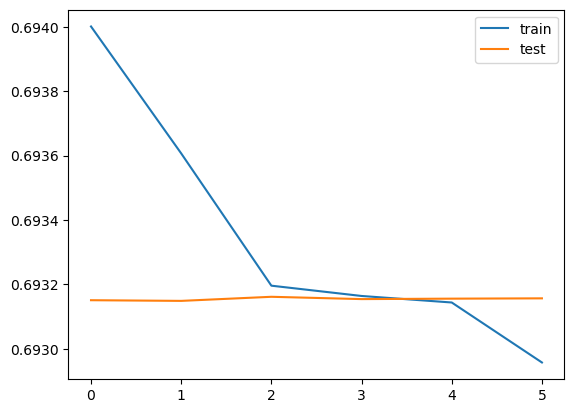

In [37]:

# Build the RNN model
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.5),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])
es = EarlyStopping(monitor='val_accuracy', mode='min', verbose=1, patience=5, restore_best_weights=True)
# Train the model
history = model.fit(X_train_, y_train, epochs=50, batch_size=100, verbose=2, validation_data=(X_val_, y_val), callbacks=[es], shuffle=True)

_, train_acc = model.evaluate(X_train_, y_train, verbose=0)
_, val_acc = model.evaluate(X_val_, y_val, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, val_acc))
# plot training history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [38]:
y_pred_proba = model.predict(X_val_)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_val, y_pred))

2/2 [==============================] - 0s 10ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        23
           1       0.00      0.00      0.00        23

    accuracy                           0.50        46
   macro avg       0.25      0.50      0.33        46
weighted avg       0.25      0.50      0.33        46



In [39]:

# Example inference
new_sequences = tokenizer.texts_to_sequences(X_test)
X_test_ = pad_sequences(new_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

y_pred_proba = model.predict(X_test_)
y_pred = (y_pred_proba > 0.5).astype(int)


13/13 [==============================] - 0s 5ms/step


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.99      0.80       255
           1       0.77      0.07      0.14       135

    accuracy                           0.67       390
   macro avg       0.72      0.53      0.47       390
weighted avg       0.70      0.67      0.57       390



In [48]:
test["pred_prob_0"] = y_pred_proba
test["pred"] = y_pred
test

,title,source,topic,ticker,company name(s) - cleaned,date,sentiment_label,pred,pred_prob_0
275,Apple honors 2024 App Store Award winners - Ap...,https://news.google.com/rss/articles/CBMiiAFBV...,NaN,AAPL,NaN,2024-12-11,0,0,0.499896
302,Apple shares target increased on strong execut...,https://news.google.com/rss/articles/CBMirgFBV...,NaN,AAPL,NaN,2024-12-13,0,0,0.499875
642,Abbott Laboratories Enters into Five Year Cred...,SEC Form 8k,Health Care Equipment,ABT,Abbott Laboratories,2024-01-29,1,1,0.500070
986,Accenture Acquires True North Solutions to Hel...,https://news.google.com/rss/articles/CBMi1gFBV...,NaN,ACN,NaN,2024-07-09,0,0,0.499880
1067,Accenture plc (NYSE:ACN) acquired Award Soluti...,Capital IQ Transaction Database,Accenture plc (NYSE:ACN) (IT Consulting and Ot...,ACN,Accenture plc,2024-11-21,0,0,0.499900
...,...,...,...,...,...,...,...,...,...
60019,Does the Fed s Lowering the Interest Rates Str...,https://mises.org/podcasts/audio-mises-wire/do...,economics,WAB,NaN,2024-12-03,1,0,0.499880
60499,WEC Energy Group Reports Strong Growth and Fut...,https://news.google.com/rss/articles/CBMiqwFBV...,NaN,WEC,NaN,2024-12-06,1,0,0.499893
60612,Wells Fargo & Company Approves and Adopts the ...,SEC Form 8k,Diversified Banks,WFC,Wells Fargo & Company,2024-01-24,1,0,0.499849
61338,West Pharma Wins Behavioral Safety Award at 20...,https://news.google.com/rss/articles/CBMiggFBV...,NaN,WST,NaN,2024-09-26,0,0,0.499993


In [50]:
test.to_csv('results/rnn_results.csv', index=False)